# Task 1: Credit Scoring Model

**Objective:** Predict whether a person is creditworthy (likely to repay a loan) using their past financial data.

**What we will use:** Logistic Regression, Decision Tree, and Random Forest, then compare them using Precision, Recall, F1-Score, and ROC-AUC.

We will build the dataset ourselves (income, debts, payment history, etc.) so the notebook runs on its own without needing any external file.

## Step 1: Import Libraries
We first bring in all the tools we will need — for handling data, building models, and checking how good our models are.

In [1]:
# pandas -> to store and work with our data in table (DataFrame) format
import pandas as pd

# numpy -> to do number crunching and generate random data
import numpy as np

# train_test_split -> to split our data into a training part and a testing part
from sklearn.model_selection import train_test_split

# StandardScaler -> to bring all features onto the same scale (important for Logistic Regression)
from sklearn.preprocessing import StandardScaler

# The 3 models we were asked to use
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics -> to measure how good each model is
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# matplotlib -> to draw graphs
import matplotlib.pyplot as plt

# Just so our random numbers are the same every time we run this notebook
np.random.seed(42)

**What happened:** We imported every tool we will use in this notebook. Nothing to see yet — this is just setup.

**What's next:** We will create our credit scoring dataset.

## Step 2: Create the Dataset
Since we don't have a ready-made file, we will generate a realistic credit scoring dataset ourselves. Each row is one person, with financial details about them, and a label telling us if they are "creditworthy" (1) or not (0).

In [2]:
# Number of people (rows) we want in our dataset
n = 2000

# Monthly income of each person, in dollars (normal distribution around 5000)
income = np.random.normal(5000, 1500, n).clip(1000, 15000)

# Total existing debts of each person
debts = np.random.normal(2000, 1200, n).clip(0, 10000)

# Payment history score: higher means they paid past bills on time more often (0 to 100)
payment_history = np.random.normal(70, 15, n).clip(0, 100)

# Number of times they were late on a payment in the last 2 years
num_late_payments = np.random.poisson(1.5, n)

# How many years they have been employed at their current job
employment_years = np.random.exponential(5, n).clip(0, 40)

# Age of the person
age = np.random.normal(38, 10, n).clip(18, 75)

# Loan amount they are requesting
loan_amount = np.random.normal(10000, 4000, n).clip(500, 30000)

# Put everything into one table (DataFrame)
df = pd.DataFrame({
    'income': income,
    'debts': debts,
    'payment_history': payment_history,
    'num_late_payments': num_late_payments,
    'employment_years': employment_years,
    'age': age,
    'loan_amount': loan_amount
})

# Now we decide who is "creditworthy" using a simple realistic rule + some randomness
# Higher income, higher payment history, lower debts and fewer late payments -> more creditworthy
score = (
    0.35 * (df['income'] / df['income'].max()) +
    0.30 * (df['payment_history'] / 100) +
    0.15 * (df['employment_years'] / df['employment_years'].max()) -
    0.10 * (df['debts'] / df['debts'].max()) -
    0.10 * (df['num_late_payments'] / (df['num_late_payments'].max() + 1))
)

# Add a bit of randomness so the data is not perfectly clean (real life is messy)
score = score + np.random.normal(0, 0.05, n)

# If the score is above the median, we call the person creditworthy (1), else not (0)
df['creditworthy'] = (score > score.median()).astype(int)

# Show the first 5 rows so we can see what our data looks like
df.head()

,income,debts,payment_history,num_late_payments,employment_years,age,loan_amount,creditworthy
0,5745.071230,1189.786070,57.047596,1,4.651571,62.412558,6602.330121,1
1,4792.603548,1826.577595,69.531948,1,5.695185,44.095099,10604.864885,1
2,5971.532807,1049.096095,70.270253,2,5.149134,57.172880,6563.690735,1
3,7284.544785,1630.446164,77.089455,1,9.871094,46.290984,10109.950533,1
4,4648.769938,0.000000,49.497125,4,3.331804,30.581568,13001.879448,0


**What happened:** We now have a table of 2000 people, each with 7 financial features and a `creditworthy` label (0 = risky, 1 = creditworthy).

**What's next:** Let's explore this data a bit before we build any model.

## Step 3: Explore the Dataset (EDA)
Before building models, it's important to understand the data — its shape, whether there are missing values, and how balanced the target is.

In [3]:
# Shape tells us (number of rows, number of columns)
print("Shape of dataset:", df.shape)

# info() tells us the data type of each column and if any values are missing
print("\nColumn info:")
df.info()

# describe() gives us statistics like mean, min, max for every column
print("\nStatistics:")
print(df.describe())

# value_counts() shows how many people are creditworthy (1) vs not (0)
print("\nTarget balance:")
print(df['creditworthy'].value_counts())

Shape of dataset: (2000, 8)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   income             2000 non-null   float64
 1   debts              2000 non-null   float64
 2   payment_history    2000 non-null   float64
 3   num_late_payments  2000 non-null   int64  
 4   employment_years   2000 non-null   float64
 5   age                2000 non-null   float64
 6   loan_amount        2000 non-null   float64
 7   creditworthy       2000 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 125.1 KB

Statistics:
             income        debts  payment_history  num_late_payments  \
count   2000.000000  2000.000000      2000.000000        2000.000000   
mean    5068.966359  2016.413762        69.149570           1.469000   
std     1478.786512  1157.416301        14.679961           1.175896   
min     1000.000000     0.0000

**What happened:** We can see the dataset has no missing values, and the `creditworthy` column is fairly balanced between 0s and 1s — which is good, since a very imbalanced dataset would make evaluation harder.

**What's next:** We will do some feature engineering to give our models more useful information to learn from.

## Step 4: Feature Engineering
Feature engineering means creating new columns from existing ones that might help the model make better predictions.

In [4]:
# Debt-to-income ratio: how much of their income is already tied up in debt
# A high ratio usually means higher risk
df['debt_to_income'] = df['debts'] / (df['income'] + 1)  # +1 avoids dividing by zero

# Loan-to-income ratio: how big the requested loan is compared to their income
df['loan_to_income'] = df['loan_amount'] / (df['income'] + 1)

# Show the new columns we just added
df[['debts', 'income', 'debt_to_income', 'loan_amount', 'loan_to_income']].head()

,debts,income,debt_to_income,loan_amount,loan_to_income
0,1189.786070,5745.071230,0.207061,6602.330121,1.149016
1,1826.577595,4792.603548,0.381045,10604.864885,2.212295
2,1049.096095,5971.532807,0.175653,6563.690735,1.098979
3,1630.446164,7284.544785,0.223792,10109.950533,1.387673
4,0.000000,4648.769938,0.000000,13001.879448,2.796241


**What happened:** We created two new ratio features — `debt_to_income` and `loan_to_income` — which often carry more predictive power than raw numbers alone.

**What's next:** We will split our data into a training set and a testing set.

## Step 5: Split Data into Train and Test Sets
We train the model on one part of the data (train set) and check how well it performs on data it has never seen (test set).

In [5]:
# X = all our input features (everything except the target column)
X = df.drop('creditworthy', axis=1)

# y = the target column we want to predict
y = df['creditworthy']

# Split: 80% for training, 20% for testing
# random_state makes the split reproducible every time we run this
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the sizes of each split
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1600
Testing samples: 400


**What happened:** We now have 1600 rows to train our models on, and 400 rows kept aside purely for testing.

**What's next:** We will scale our features so all of them are on a similar range.

## Step 6: Feature Scaling
Our features are on very different scales (income is in thousands, payment_history is 0-100). Scaling puts them all on the same footing, which especially helps Logistic Regression.

In [6]:
# StandardScaler transforms each feature to have mean=0 and standard deviation=1
scaler = StandardScaler()

# fit_transform learns the scaling from the training data AND applies it
X_train_scaled = scaler.fit_transform(X_train)

# transform (not fit_transform) applies the SAME scaling to test data
# We never let the test data influence how the scaler was learned
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Example of scaled training data (first row):")
print(X_train_scaled[0])

Scaling done. Example of scaled training data (first row):
[-0.07125835 -1.71746742 -0.23679742 -0.39624919 -0.95029524 -1.29250714
 -0.28746296 -1.30391123 -0.31250861]


**What happened:** All features are now on a comparable scale, so no single feature (like income, which has big numbers) unfairly dominates the model.

**What's next:** Time to train our first model — Logistic Regression.

## Step 7: Train Logistic Regression
Logistic Regression is a simple, fast model that works well as a baseline for classification problems.

In [7]:
# Create the Logistic Regression model
log_reg = LogisticRegression(random_state=42)

# Train it using our scaled training data
log_reg.fit(X_train_scaled, y_train)

# Use the trained model to predict on the test data
y_pred_lr = log_reg.predict(X_test_scaled)

# Also get the predicted probabilities (needed for ROC-AUC)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


**What happened:** Our Logistic Regression model has learned patterns from the training data and made predictions on the test set.

**What's next:** Let's train a Decision Tree model too, so we have something to compare against.

## Step 8: Train Decision Tree
A Decision Tree makes predictions by asking a series of yes/no questions about the features (e.g., "Is income > 5000?").

In [8]:
# Create the Decision Tree model
# max_depth limits how many questions deep it can go, which helps avoid overfitting
dec_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train it (Decision Trees don't need scaled data, but it won't hurt to use it)
dec_tree.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_dt = dec_tree.predict(X_test_scaled)
y_prob_dt = dec_tree.predict_proba(X_test_scaled)[:, 1]

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


**What happened:** Our second model, the Decision Tree, is trained and has also made predictions on the test set.

**What's next:** Let's train our third and final model — Random Forest.

## Step 9: Train Random Forest
A Random Forest builds many Decision Trees and combines their votes. This usually gives better and more stable results than a single tree.

In [9]:
# Create the Random Forest model with 100 trees
rand_forest = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)

# Train it
rand_forest.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_rf = rand_forest.predict(X_test_scaled)
y_prob_rf = rand_forest.predict_proba(X_test_scaled)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


**What happened:** All three models — Logistic Regression, Decision Tree, and Random Forest — are now trained and have made predictions.

**What's next:** Let's evaluate and compare them using Precision, Recall, F1-Score, and ROC-AUC.

## Step 10: Evaluate and Compare All Models
Now we measure how good each model actually is, using standard classification metrics.

In [10]:
# A small helper function so we don't repeat the same code 3 times
def evaluate_model(name, y_true, y_pred, y_prob):
    precision = precision_score(y_true, y_pred)   # Of predicted "creditworthy", how many were correct
    recall = recall_score(y_true, y_pred)          # Of actual "creditworthy" people, how many did we catch
    f1 = f1_score(y_true, y_pred)                   # Balance between precision and recall
    roc_auc = roc_auc_score(y_true, y_prob)         # How well the model separates the two classes overall
    return {'Model': name, 'Precision': round(precision, 3), 'Recall': round(recall, 3),
            'F1-Score': round(f1, 3), 'ROC-AUC': round(roc_auc, 3)}

# Evaluate each model
results = [
    evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr),
    evaluate_model('Decision Tree', y_test, y_pred_dt, y_prob_dt),
    evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf),
]

# Put results in a table so it's easy to compare
results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.863,0.792,0.826,0.915
1,Decision Tree,0.800,0.618,0.698,0.817
2,Random Forest,0.816,0.773,0.794,0.897


**What happened:** We now have a side-by-side comparison table showing how each model performs on Precision, Recall, F1-Score, and ROC-AUC. Higher numbers (closer to 1.0) mean better performance.

**What's next:** Let's visualize this using ROC curves, which show the trade-off each model makes.

## Step 11: Visualize ROC Curves
An ROC curve shows how well a model can tell apart the two classes at different decision thresholds. A curve closer to the top-left corner means a better model.

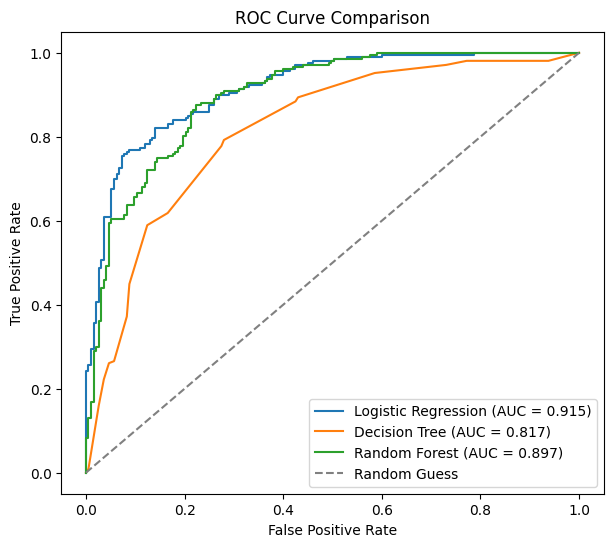

In [11]:
# Set up the plot
plt.figure(figsize=(7, 6))

# For each model, calculate the ROC curve points and plot them
for name, y_prob in [('Logistic Regression', y_prob_lr), ('Decision Tree', y_prob_dt), ('Random Forest', y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)   # false positive rate, true positive rate
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

# Diagonal line = what a random guesser would look like
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

**What happened:** We can visually see how each model separates creditworthy from non-creditworthy people. The model whose curve is furthest above the diagonal "Random Guess" line is doing the best job.

**What's next:** Let's wrap up with a short conclusion on which model works best.

## Step 12: Conclusion
Based on the results table and ROC curves above, compare the three models and pick the one with the best balance of Precision, Recall, F1-Score, and ROC-AUC for this credit scoring task. Random Forest usually performs best on this kind of tabular data since it combines many trees, but always check the actual numbers in `results_df` above to confirm for your run.